<a href="https://colab.research.google.com/github/ManasaRubini/Internship/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [326]:
#preprocessing

In [327]:
import pandas as pd

In [328]:
df = pd.read_csv('preprocessing_dataset.csv')

In [329]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()

In [330]:
df.shape

(10, 5)

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [332]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [333]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [334]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [335]:
df.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [336]:
#Identifying missing values as graph
!pip install missingno

<Axes: >

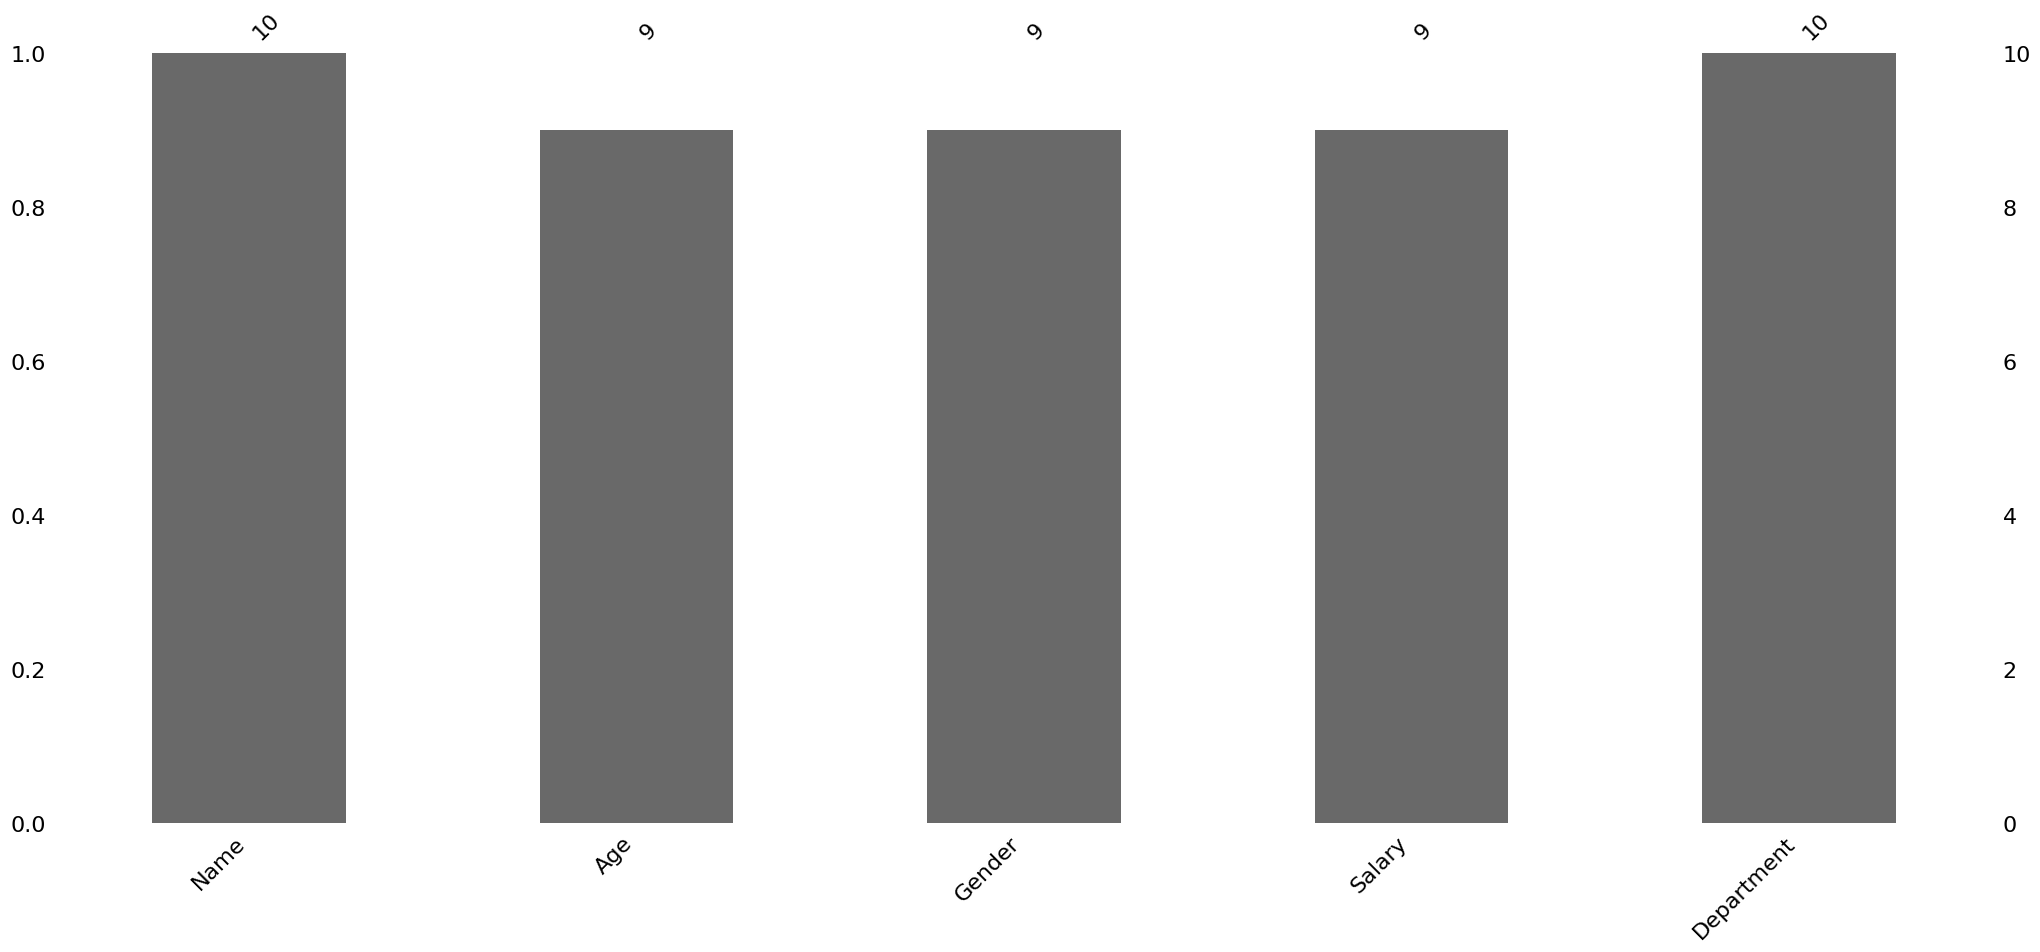

In [337]:
import missingno as mn
mn.bar(df)

<Axes: >

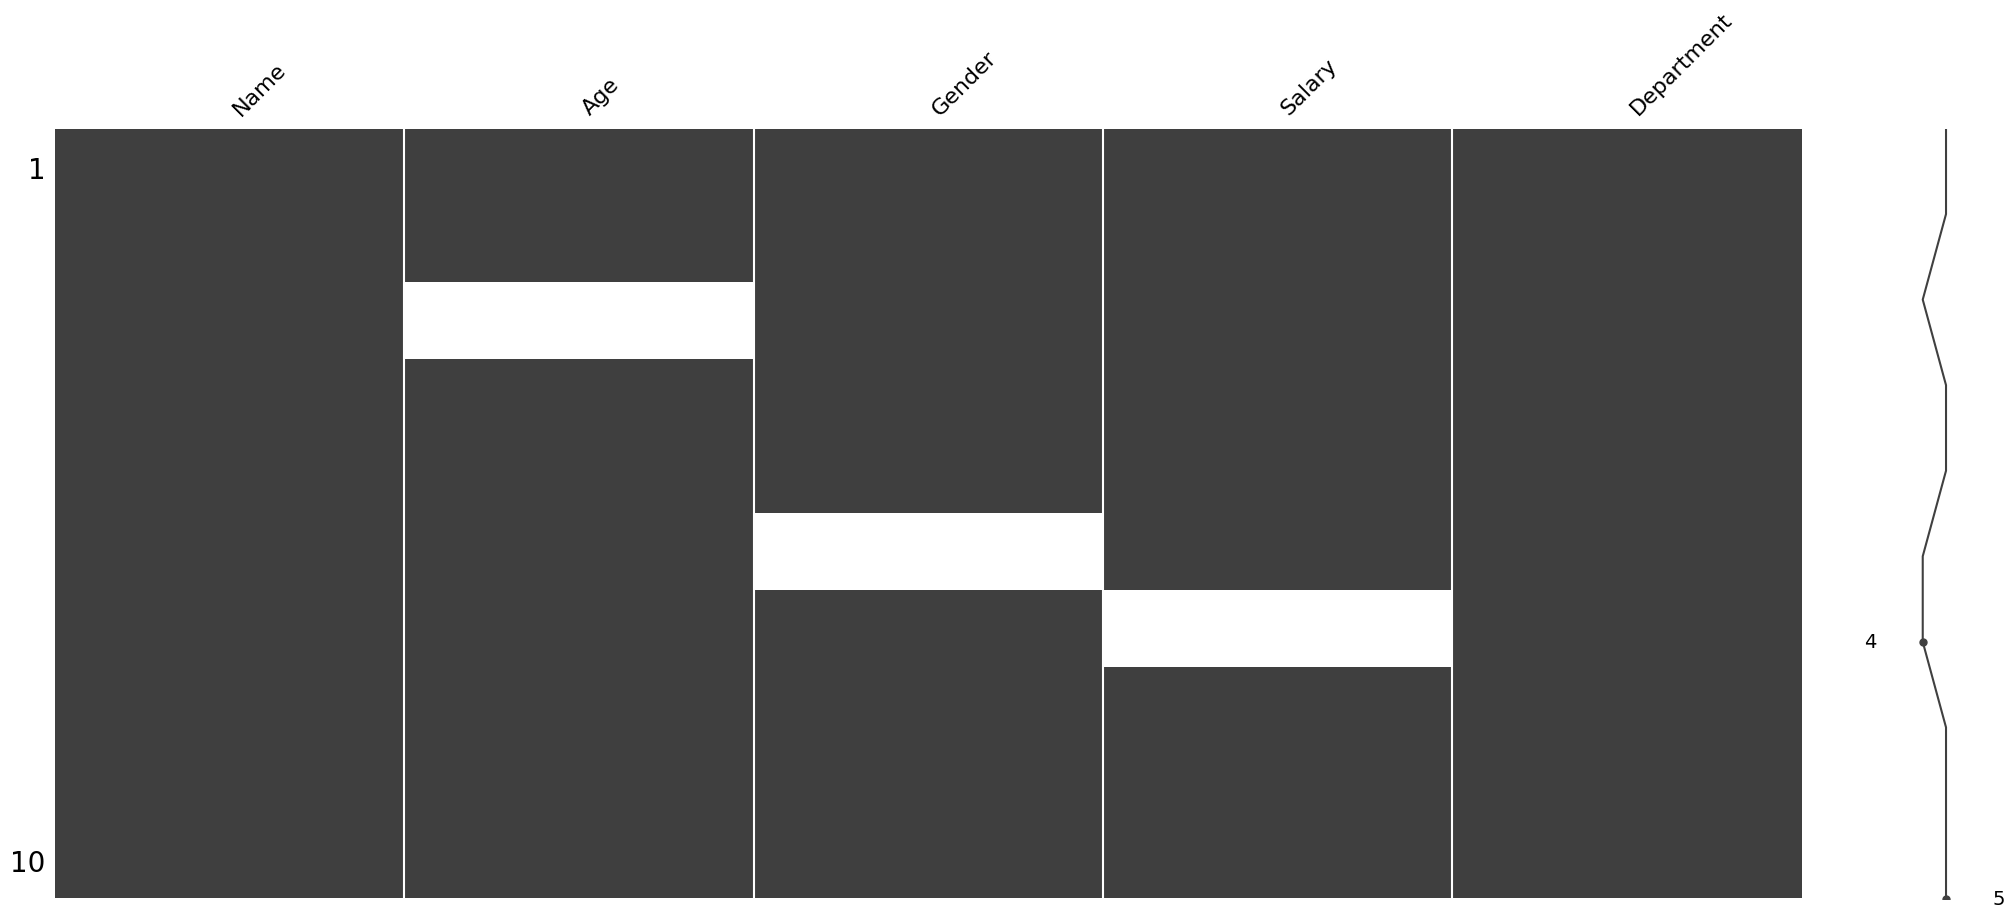

In [338]:
mn.matrix(df)

<Axes: >

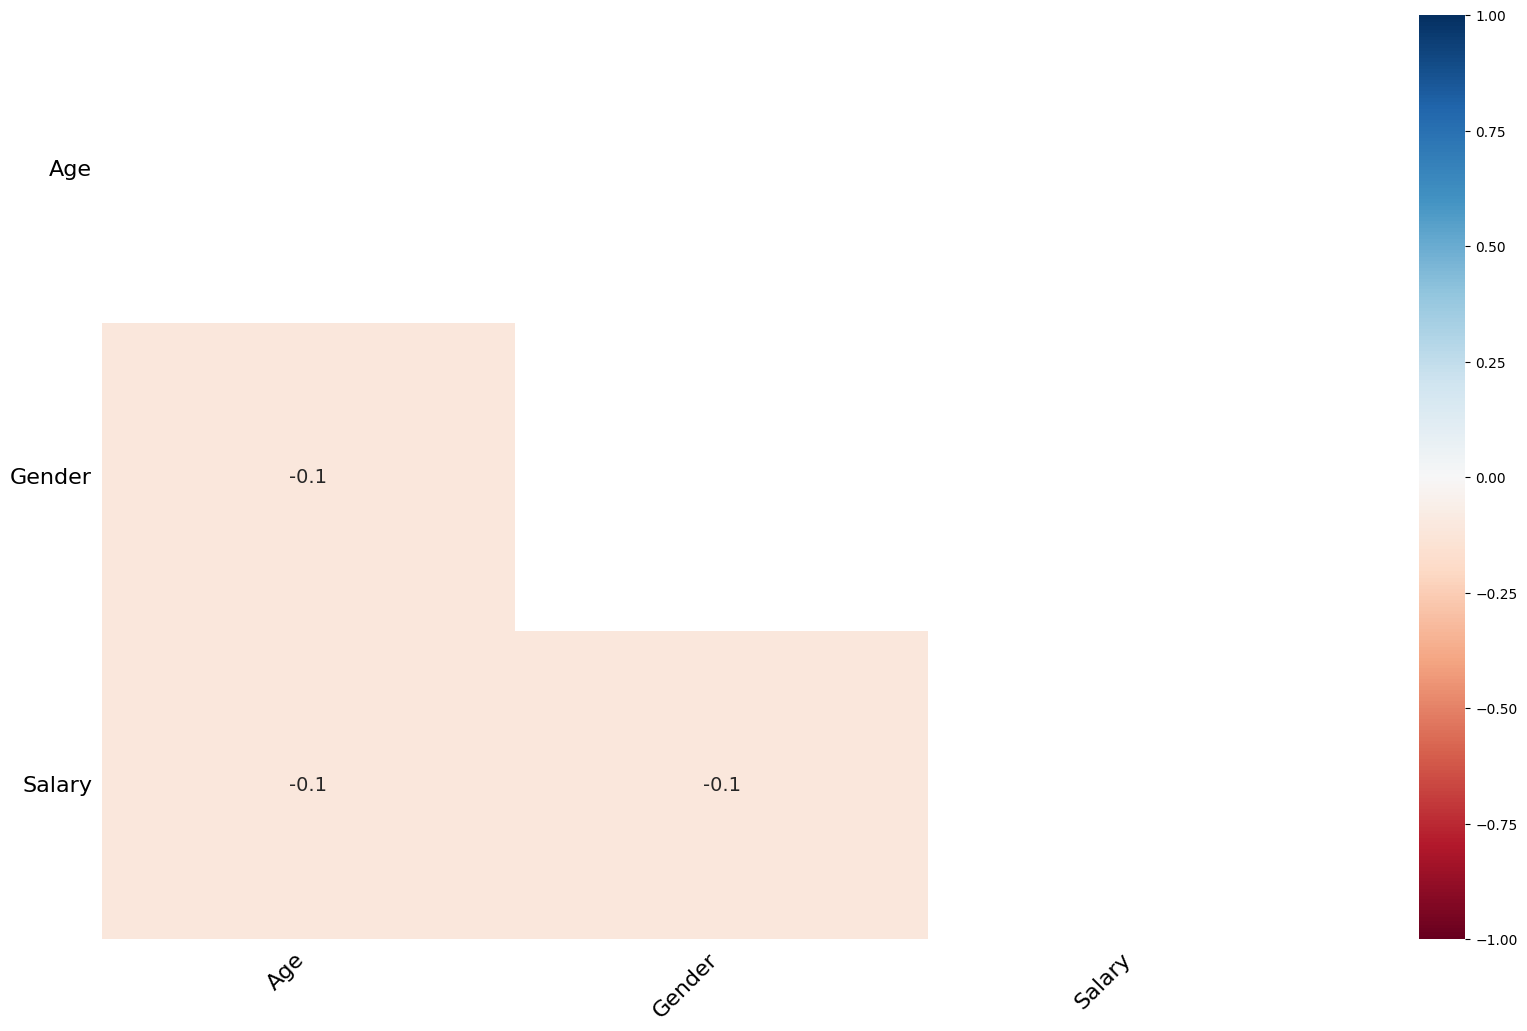

In [339]:
mn.heatmap(df)

<Axes: >

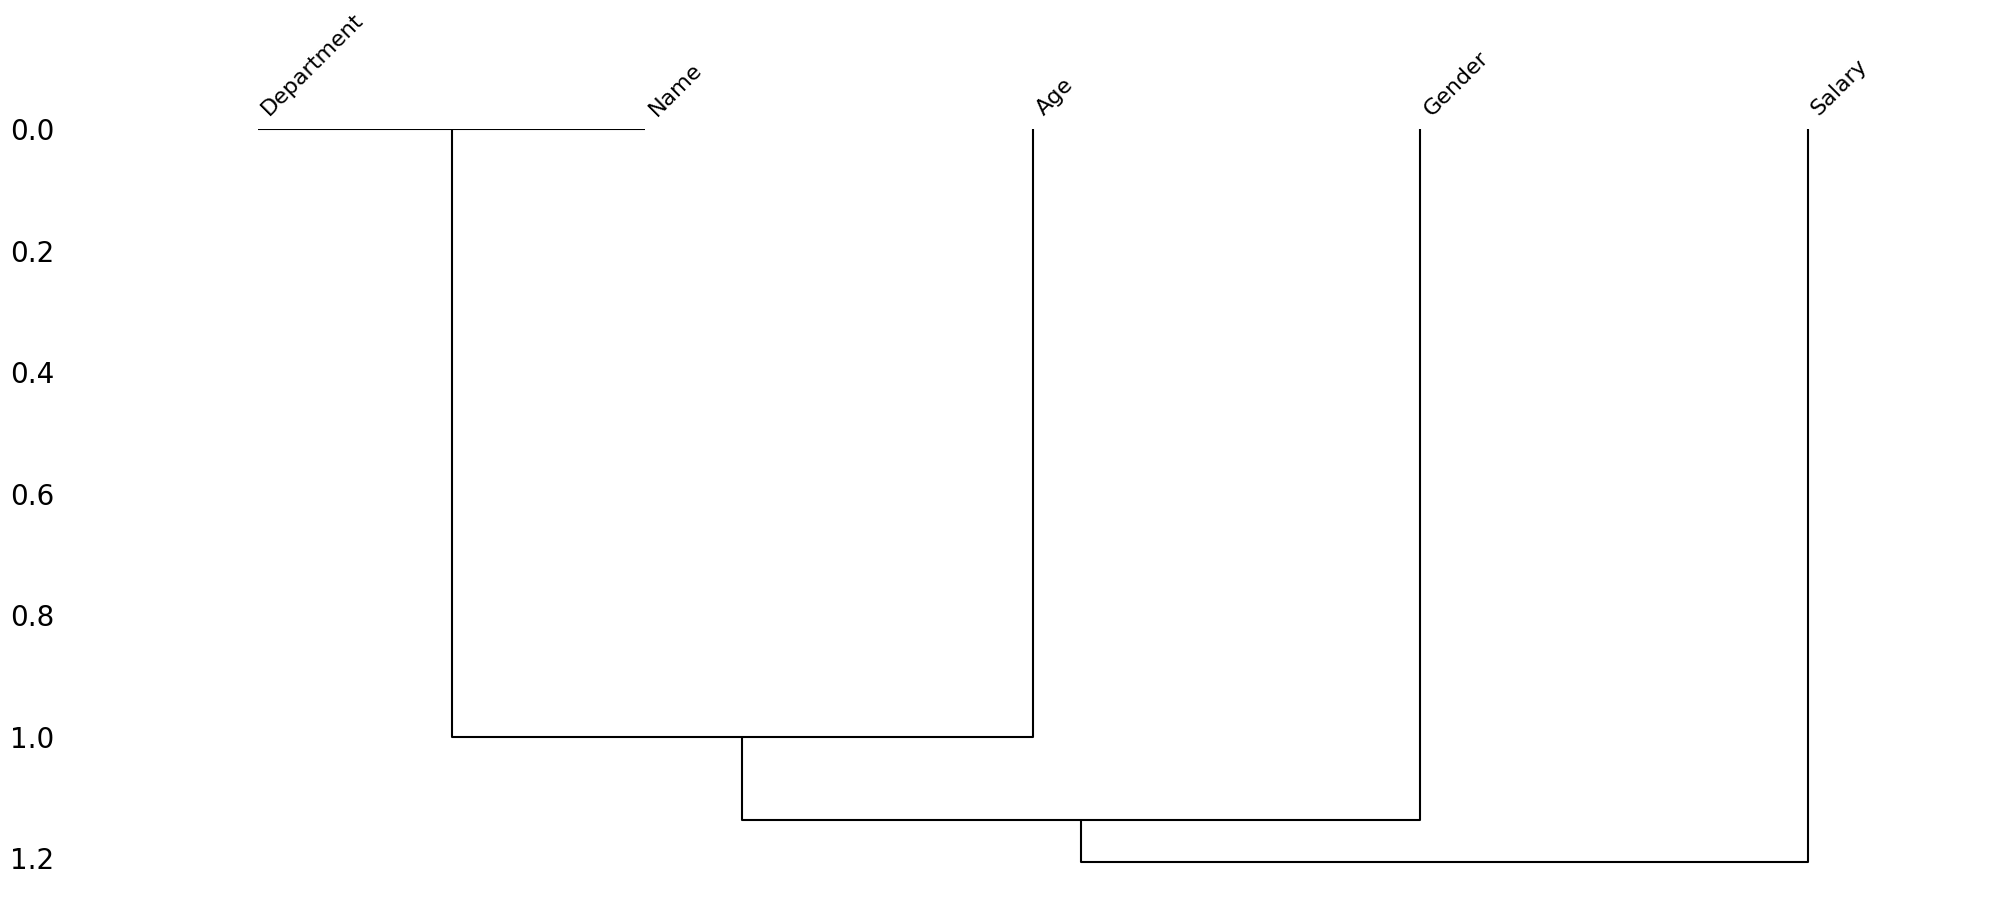

In [340]:
mn.dendrogram(df)

<Axes: >

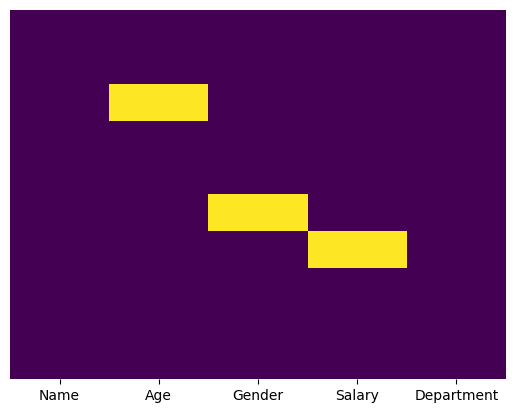

In [341]:
#heatmap is used to know about the association between two values
import seaborn as sns
sns.heatmap(df.isnull(),yticklabels = False ,cbar = False,cmap = 'viridis')

In [342]:
df['Age'].fillna(df['Age'].mean(), inplace = True)
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)

/tmp/ipykernel_495/2693633672.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace = True)
/tmp/ipykernel_495/2693633672.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [343]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy = 'mean')
df1[['Age']] = si.fit_transform(df1[['Age']])

In [344]:
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.0,HR
1,Bob,30.000000,M,60000.0,Finance
2,Charlie,39.555556,M,55000.0,IT
3,David,40.000000,M,58000.0,HR
4,Eve,22.000000,F,52000.0,IT
5,Frank,35.000000,NaN,61000.0,Finance
6,Grace,120.000000,F,NaN,Finance
7,Henry,28.000000,M,59000.0,HR
8,Ivy,29.000000,F,63000.0,IT
9,Jack,27.000000,M,62000.0,Finance


In [345]:
#Finding Outlier

<Axes: ylabel='Salary'>

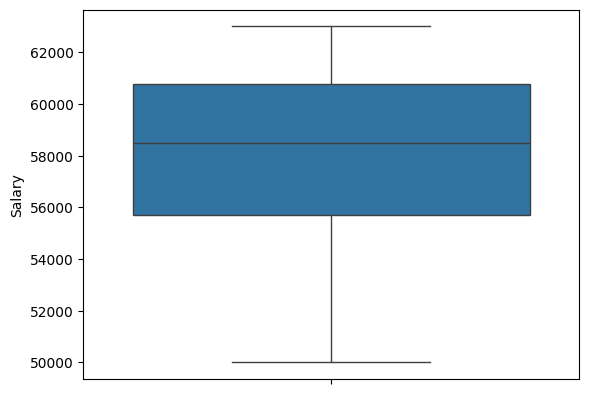

In [346]:
sns.boxplot(df['Salary'])


<Axes: ylabel='Age'>

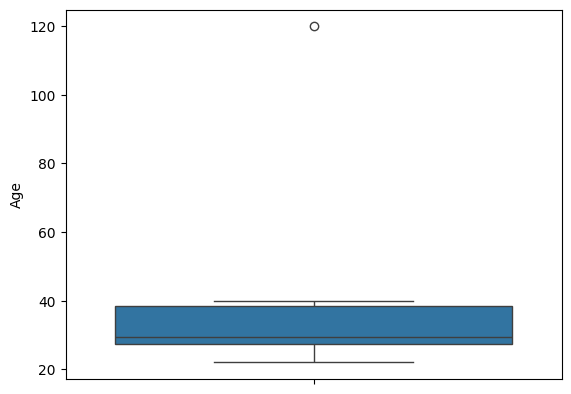

In [347]:
sns.boxplot(df['Age'])

In [348]:
q1 = df1['Age'].quantile(0.25)
q3 = df1['Age'].quantile(0.75)

iqr =  q3-q1
minimum = q1-1.5*iqr
maximum = q3+1.5*iqr

outlier = (df1['Age'] < minimum) | (df1['Age'] > maximum)
df1[outlier]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [349]:
import numpy as np
from scipy.stats import zscore
z_score = zscore(df['Age'])
df[np.abs(z_score)>2.9]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [350]:
from sklearn.ensemble import IsolationForest
isf = IsolationForest(contamination=0.1)
df['outlier'] = isf.fit_predict(df[['Age','Salary']])
df[df['outlier']==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


In [351]:
df['outlier']


,outlier
0,1
1,1
2,1
3,1
4,1
5,1
6,-1
7,1
8,1
9,1


In [352]:
#Handling outliers
#using winsorization method
from scipy.stats.mstats import winsorize
df['Age_Winsorized'] = winsorize(df['Age'], limits=[0, 0.1])
print(df[['Age', 'Age_Winsorized']])

          Age  Age_Winsorized
0   25.000000       25.000000
1   30.000000       30.000000
2   39.555556       39.555556
3   40.000000       40.000000
4   22.000000       22.000000
5   35.000000       35.000000
6  120.000000       40.000000
7   28.000000       28.000000
8   29.000000       29.000000
9   27.000000       27.000000


In [353]:
#using log transform method
df['Log_Salary'] = np.log(df['Salary']) # df['Log_Salary'] = np.log1p(df['Salary'])  (safer method)
print(df[['Salary', 'Log_Salary']])

         Salary  Log_Salary
0  50000.000000   10.819778
1  60000.000000   11.002100
2  55000.000000   10.915088
3  58000.000000   10.968198
4  52000.000000   10.858999
5  61000.000000   11.018629
6  57777.777778   10.964360
7  59000.000000   10.985293
8  63000.000000   11.050890
9  62000.000000   11.034890


In [354]:
# using power transform method
# boxcox method
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')
df[['Salary_BoxCox']] = pt.fit_transform(df[['Salary']])
print(df[['Salary', 'Salary_BoxCox']])

         Salary  Salary_BoxCox
0  50000.000000      -1.651983
1  60000.000000       0.468101
2  55000.000000      -0.829770
3  58000.000000      -0.119687
4  52000.000000      -1.369532
5  61000.000000       0.801322
6  57777.777778      -0.178982
7  59000.000000       0.161683
8  63000.000000       1.555656
9  62000.000000       1.163193


In [355]:
# yeo-johnson method
pt = PowerTransformer(method='yeo-johnson')
df[['Age_Transformed']] = pt.fit_transform(df[['Age']])
print(df[['Age', 'Age_Transformed']])

          Age  Age_Transformed
0   25.000000        -0.966514
1   30.000000        -0.100378
2   39.555556         0.784877
3   40.000000         0.812389
4   22.000000        -1.758521
5   35.000000         0.445352
6  120.000000         1.987909
7   28.000000        -0.396398
8   29.000000        -0.241400
9   27.000000        -0.567315


In [356]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df[['Age_Standard']] = sc.fit_transform(df[['Age']])
print(df[['Age', 'Age_Standard']])

          Age  Age_Standard
0   25.000000     -0.531273
1   30.000000     -0.348775
2   39.555556      0.000000
3   40.000000      0.016222
4   22.000000     -0.640773
5   35.000000     -0.166276
6  120.000000      2.936198
7   28.000000     -0.421774
8   29.000000     -0.385275
9   27.000000     -0.458274


In [357]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df[['Age_MinMax']] = mm.fit_transform(df[['Age']])
print(df[['Age', 'Age_MinMax']])

          Age  Age_MinMax
0   25.000000    0.030612
1   30.000000    0.081633
2   39.555556    0.179138
3   40.000000    0.183673
4   22.000000    0.000000
5   35.000000    0.132653
6  120.000000    1.000000
7   28.000000    0.061224
8   29.000000    0.071429
9   27.000000    0.051020


In [358]:
# ENCODING
#Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df3['Gender_encoded'] = le.fit_transform(df3['Gender'])
df3

,Name,Age,Gender,Salary,Department,Gender_encoded
0,Alice,25.0,F,50000.0,HR,0
1,Bob,30.0,M,60000.0,Finance,1
2,Charlie,NaN,M,55000.0,IT,1
3,David,40.0,M,58000.0,HR,1
4,Eve,22.0,F,52000.0,IT,0
5,Frank,35.0,NaN,61000.0,Finance,2
6,Grace,120.0,F,NaN,Finance,0
7,Henry,28.0,M,59000.0,HR,1
8,Ivy,29.0,F,63000.0,IT,0
9,Jack,27.0,M,62000.0,Finance,1


In [359]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False)
df3['Department'] = ohe.fit_transform(df3[['Department']])
df3

,Name,Age,Gender,Salary,Department,Gender_encoded
0,Alice,25.0,F,50000.0,0.0,0
1,Bob,30.0,M,60000.0,1.0,1
2,Charlie,NaN,M,55000.0,0.0,1
3,David,40.0,M,58000.0,0.0,1
4,Eve,22.0,F,52000.0,0.0,0
5,Frank,35.0,NaN,61000.0,1.0,2
6,Grace,120.0,F,NaN,1.0,0
7,Henry,28.0,M,59000.0,0.0,1
8,Ivy,29.0,F,63000.0,0.0,0
9,Jack,27.0,M,62000.0,1.0,1


In [360]:
df3 = pd.get_dummies(df3,columns=['Gender'])
df3

,Name,Age,Salary,Department,Gender_encoded,Gender_F,Gender_M
0,Alice,25.0,50000.0,0.0,0,True,False
1,Bob,30.0,60000.0,1.0,1,False,True
2,Charlie,NaN,55000.0,0.0,1,False,True
3,David,40.0,58000.0,0.0,1,False,True
4,Eve,22.0,52000.0,0.0,0,True,False
5,Frank,35.0,61000.0,1.0,2,False,False
6,Grace,120.0,NaN,1.0,0,True,False
7,Henry,28.0,59000.0,0.0,1,False,True
8,Ivy,29.0,63000.0,0.0,0,True,False
9,Jack,27.0,62000.0,1.0,1,False,True
